In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Part 1: Data Cleaning

> **Data source:** Download the MoMA dataset from [Kaggle]([https://www.kaggle.com/datasets/mfrancis23/museum-of-modern-art-collection](https://www.kaggle.com/datasets/mfrancis23/museum-of-modern-art-collection)) and place `Artworks.csv` and `Artists.csv` into the `data/raw/` folder before running this notebook.

We performed the following data cleaning steps:

For the `Artworks.csv` file:

1. **Load** the raw `Artworks.csv`
2. **Remove duplicate titles** – deduplicate artworks by the portion of the title before the first comma
3. **Remove rows containing "Unknown"** – drop any artwork row where any column contains "Unknown" (case-insensitive)
4. **Clean the Date column** – extract the first four-digit year; drop rows with no valid year
5. **Deal with multiple authors cases** – for artworks with multiple artists, each artist is treated as a separate row.

For the `Artists.csv` file:

1. **Clean Artist column** – load `Artists.csv`, split multi-artist rows by `ConstituentID`, look up Artist name and Gender from Artists table, report remaining empty values
2. **Clean Artists** – remove artists with invalid `BeginDate`, missing `Nationality`, or missing `Gender`, then drop their corresponding artworks
3. **Select columns & export** – trim both DataFrames to essential columns and save as UTF-8 BOM CSV

# Part 2: Data Analysis from Artist perspective

> **Data source:** Use the already cleaned data files, specifically `cleaned_artists.csv` and `cleaned_artworks.csv` located under `data/`.


This notebook performs three data analyses mainly focused on artists.

# Part 3: Data Analysis from Artwork perspective

> **Data source:** We used the already cleaned data file `cleaned_artworks.csv` located under `data/`.

We categorized artworks by creation year and analyzed the following trends over time (year of artwork creation): artwork counts, geographic distribution trends by artist, geographic distribution trends by artwork, gender ratio changes, category proportions across disciplines (using classification and department respectively).

In [2]:
df = pd.read_csv("cleaned_artworks.csv")
print(f"Original shape: {df.shape}")
df.head()

Original shape: (87775, 11)


,Title,Artist,ConstituentID,Nationality,Gender,Date,Classification,Department,ObjectID,URL,ThumbnailURL
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,Austrian,Male,1896,Architecture,Architecture & Design,2,http://www.moma.org/collection/works/2,http://www.moma.org/media/W1siZiIsIjU5NDA1Il0s...
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,French,Male,1987,Architecture,Architecture & Design,3,http://www.moma.org/collection/works/3,http://www.moma.org/media/W1siZiIsIjk3Il0sWyJw...
2,"Villa near Vienna Project, Outside Vienna, Aus...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,4,http://www.moma.org/collection/works/4,http://www.moma.org/media/W1siZiIsIjk4Il0sWyJw...
3,"Villa, project, outside Vienna, Austria, Exter...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,6,http://www.moma.org/collection/works/6,http://www.moma.org/media/W1siZiIsIjEyNiJdLFsi...
4,"Memorial to the Six Million Jewish Martyrs, pr...",Louis I. Kahn,2964,American,Male,1968,Architecture,Architecture & Design,32,http://www.moma.org/collection/works/32,http://www.moma.org/media/W1siZiIsIjE3MyJdLFsi...


In [3]:
df['Gender'] = df['Gender'].replace({'female': 'Female', 'male': 'Male'})

# Create decade
df['Decade'] = (df['Date'] // 10) * 10

# Remove duplicates by ObjectID to count each artwork only once
unique_artworks = df.drop_duplicates(subset='ObjectID')

In [4]:
unique_artworks.head()

,Title,Artist,ConstituentID,Nationality,Gender,Date,Classification,Department,ObjectID,URL,ThumbnailURL,Decade
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,Austrian,Male,1896,Architecture,Architecture & Design,2,http://www.moma.org/collection/works/2,http://www.moma.org/media/W1siZiIsIjU5NDA1Il0s...,1890
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,French,Male,1987,Architecture,Architecture & Design,3,http://www.moma.org/collection/works/3,http://www.moma.org/media/W1siZiIsIjk3Il0sWyJw...,1980
2,"Villa near Vienna Project, Outside Vienna, Aus...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,4,http://www.moma.org/collection/works/4,http://www.moma.org/media/W1siZiIsIjk4Il0sWyJw...,1900
3,"Villa, project, outside Vienna, Austria, Exter...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,6,http://www.moma.org/collection/works/6,http://www.moma.org/media/W1siZiIsIjEyNiJdLFsi...,1900
4,"Memorial to the Six Million Jewish Martyrs, pr...",Louis I. Kahn,2964,American,Male,1968,Architecture,Architecture & Design,32,http://www.moma.org/collection/works/32,http://www.moma.org/media/W1siZiIsIjE3MyJdLFsi...,1960


### Part 3.1: Annual Artwork Creation Trends

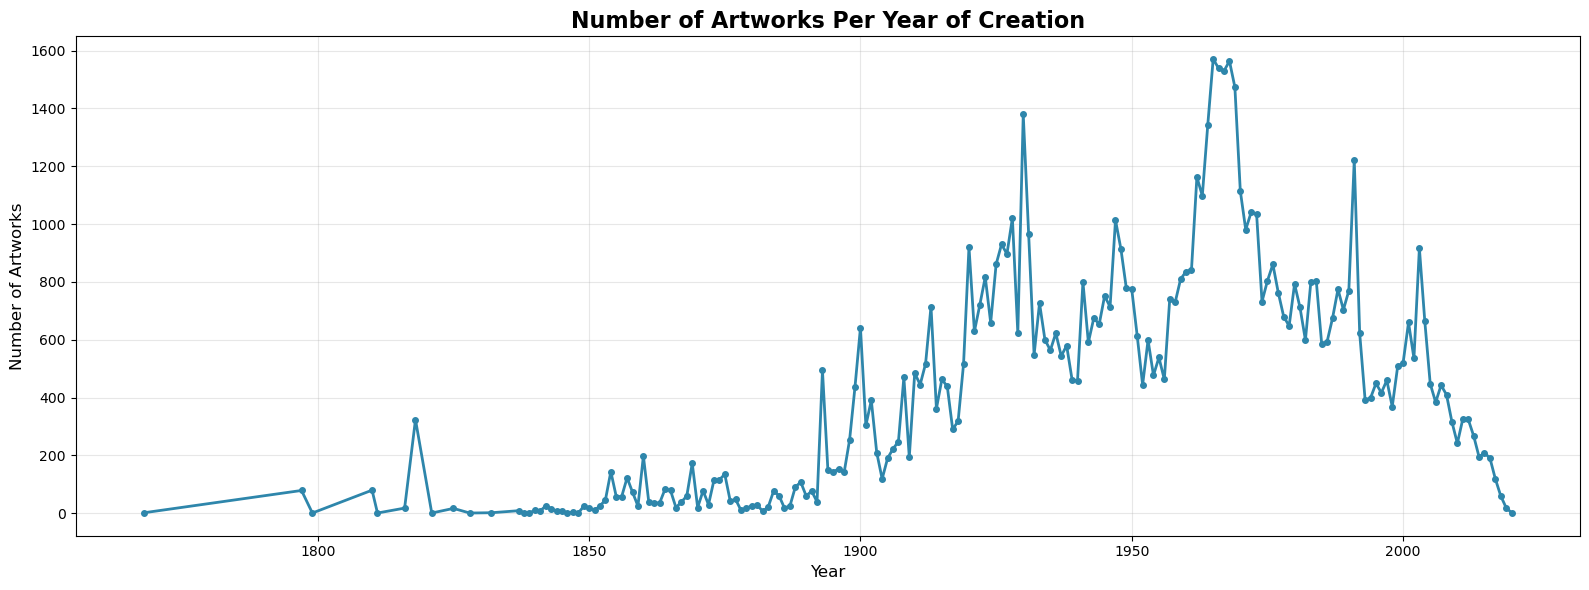

In [5]:
# Count artworks by year
yearly_counts = unique_artworks.groupby('Date').size().reset_index(name='Count')
yearly_counts = yearly_counts.sort_values('Date')

# Create single line chart
plt.figure(figsize=(16, 6))
plt.plot(yearly_counts['Date'], yearly_counts['Count'], 
         color='#2E86AB', linewidth=2, marker='o', markersize=4)

plt.title('Number of Artworks Per Year of Creation', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artworks', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('data analysis image results/Number of Artworks Per Year of Creation.png',
            dpi=300, bbox_inches='tight')

plt.show()

### Part 3.2: Geographic Distribution of Artworks Over Time

Note: some artworks are created by multiple artists. In such cases, we allocate shares proportionally. For example, if a piece is co-created by three Americans, one Japanese and one Indian, the count would be recorded as 0.6 for the U.S., 0.2 for Japan, and 0.2 for India. As a result, the final totals may include decimals.

<Figure size 1600x800 with 0 Axes>

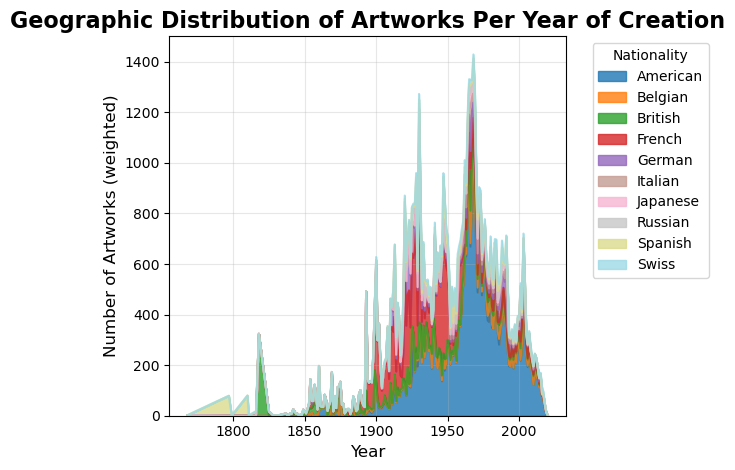


Top 50 Nationalities by Artwork Count (weighted):
Nationality
American         34718.985729
French           17372.442459
German            6294.640815
British           4422.402169
Spanish           2566.005780
Italian           1920.361680
Japanese          1586.354893
Russian           1565.307143
Swiss             1309.370810
Belgian           1070.181668
Mexican            984.515098
Dutch              922.638946
Canadian           673.419273
Austrian           666.042913
Czech              527.037233
Brazilian          506.306308
Colombian          482.421182
Ivorian            481.000000
Argentine          449.322934
Chilean            393.795635
Polish             341.458547
Danish             331.769045
South African      267.540909
Israeli            233.550000
Venezuelan         220.441379
Australian         193.598214
Chinese            187.583333
Swedish            173.087652
Finnish            129.000000
Hungarian          118.511204
Cuban              118.225433
Yugosla

In [12]:
# Calculate the weight for each artist based on the number of artists for the artwork
df['Weight'] = df.groupby('ObjectID')['ObjectID'].transform('count')  # number of artists per artwork
df['Weight'] = 1 / df['Weight']  # each artist contributes 1 / num_artists

# Now group by Nationality and Date using the weighted count
geo_time_dist = df.groupby(['Nationality', 'Date'])['Weight'].sum().reset_index(name='Count')

# Get top 10 nationalities
top_nats = df.groupby('Nationality')['Weight'].sum().sort_values(ascending=False).head(10).index.tolist()
df_top_nats = geo_time_dist[geo_time_dist['Nationality'].isin(top_nats)]

# Create pivot table and plot
pivot_data = df_top_nats.pivot_table(index='Date', columns='Nationality', values='Count', fill_value=0)

plt.figure(figsize=(16, 8))
pivot_data.plot.area(stacked=True, alpha=0.8, colormap='tab20')
plt.title('Geographic Distribution of Artworks Per Year of Creation', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artworks (weighted)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nationality')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data analysis image results/Geographic Distribution of Artworks Per Year of Creation.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Print top 50 nationalities by weighted artwork count
print("\nTop 50 Nationalities by Artwork Count (weighted):")
print(df.groupby('Nationality')['Weight'].sum().sort_values(ascending=False).head(50))

### Part 3.3: Geographic Distribution of Artists Over Time (based on the year of artwork creation)

Note: Regardless of the number of shared or individual works, each artist's nationality is counted only once per year if they were active.

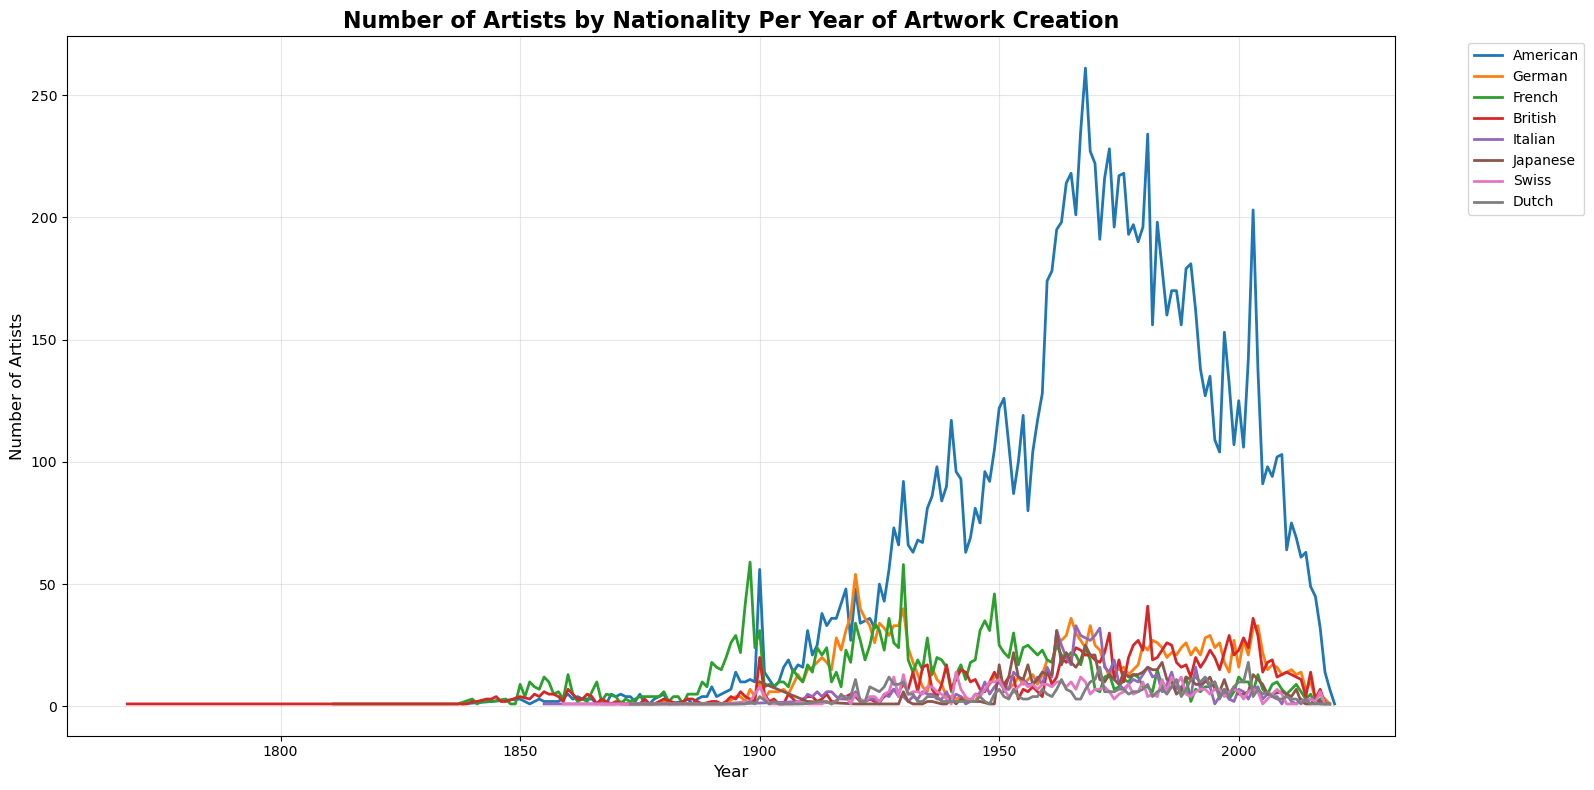

In [7]:
# Remove duplicates: each artist counts only once per year per nationality
df_unique_artists = df[['Date', 'Nationality', 'Artist']].drop_duplicates()

# Count unique artists by nationality and year
artist_geo = df_unique_artists.groupby(['Date', 'Nationality'])['Artist'].nunique().reset_index(name='Artist_Count')

# Get top 10 nationalities by artist count
top_artist_nats = df_unique_artists.groupby('Nationality')['Artist'].nunique().sort_values(ascending=False).head(10).index.tolist()
df_top_artists = artist_geo[artist_geo['Nationality'].isin(top_artist_nats)]

# Create pivot table and plot
pivot_artists = df_top_artists.pivot_table(index='Date', columns='Nationality', values='Artist_Count', fill_value=0)

plt.figure(figsize=(16, 8))
for nationality in top_artist_nats[:8]:
    data = df_top_artists[df_top_artists['Nationality'] == nationality]
    plt.plot(data['Date'], data['Artist_Count'], label=nationality, linewidth=2)

plt.title('Number of Artists by Nationality Per Year of Artwork Creation', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data analysis image results/Number of Artists by Nationality Per Year of Artwork Creation.png',
            dpi=300, bbox_inches='tight')
plt.show()

We print the top 10 countries with most active artists in 1900, 1950 and 2000 respectively.

In [8]:
# Years of interest
years = [1900, 1950, 2000]

for year in years:
    df_year = df_unique_artists[df_unique_artists['Date'] == year]
    
    # Count unique artists per nationality
    top_nationalities = df_year.groupby('Nationality')['Artist'].nunique().sort_values(ascending=False).head(10)
    
    print(f"\nTop 10 nationalities by artist count in {year}:")
    print(top_nationalities.to_string(header=False))


Top 10 nationalities by artist count in 1900:
American     56
French       31
British      20
German       10
Japanese     10
Swiss         8
Austrian      4
Dutch         4
Argentine     1
Belgian       1

Top 10 nationalities by artist count in 1950:
American     122
French        25
Japanese      17
German        12
Swiss         11
British       10
Italian       10
Danish         8
Dutch          7
Brazilian      5

Top 10 nationalities by artist count in 2000:
American         125
British           23
South African     16
German            16
Austrian          14
French            12
Dutch             10
Chinese            8
Canadian           7
Italian            7


### Part 3.4: Gender Distribution of Artworks Over Time

Note: similarly with part 3.2, some artworks are created by multiple artists. In such cases, we allocate shares proportionally. For example, if a piece is co-created by 3 men and 2 women, the count would be recorded as 0.6 for men and 0.4 for women. As a result, the final totals may include decimals.

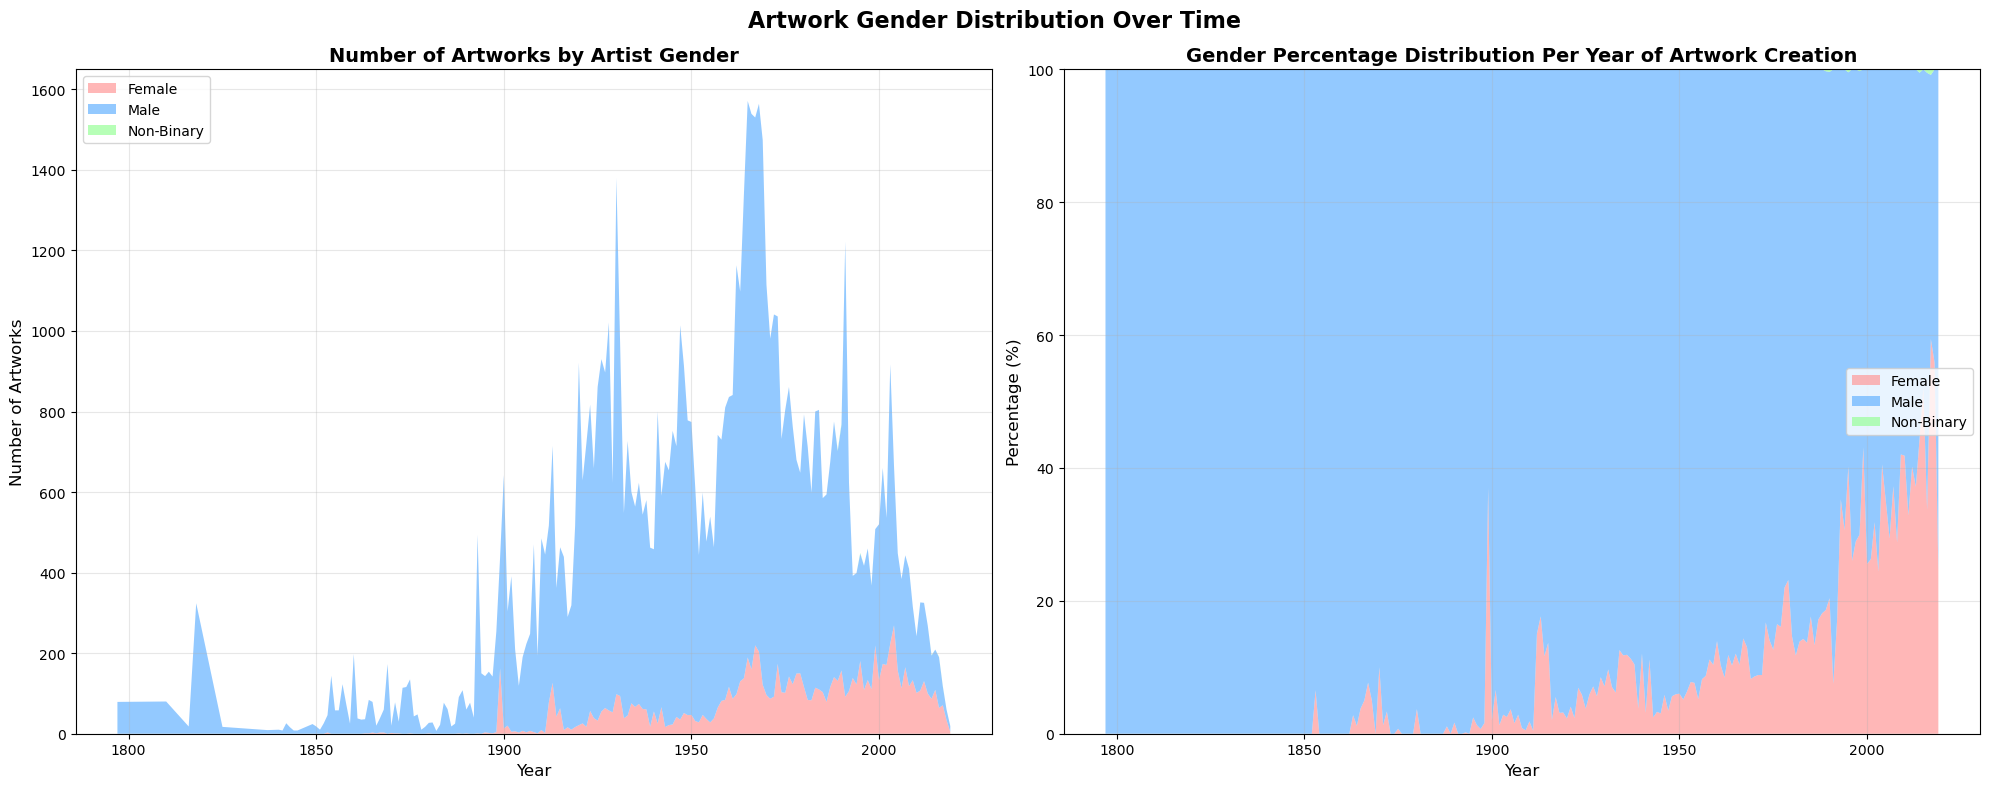


GENDER DISTRIBUTION SUMMARY (Weighted by multi-artist contributions)
Male: 72540.81 (87.72%)
Female: 10141.99 (12.26%)
Non-Binary: 11.20 (0.01%)


In [9]:
# Include all gender categories (Female, Male, Non-Binary)
df_gender = df[df['Gender'].notna()].copy()  # Keep all non-null genders

df_gender['Weight'] = 1 / df_gender.groupby('ObjectID')['ObjectID'].transform('count')
gender_by_year = df_gender.groupby(['Date', 'Gender'])['Weight'].sum().reset_index(name='Count')
gender_pivot = gender_by_year.pivot_table(index='Date', columns='Gender', values='Count', fill_value=0)
gender_categories = gender_pivot.columns.tolist()
colors = {'Female': '#ff9999', 'Male': '#66b3ff', 'Non-Binary': '#99ff99'}

# Calculate total artworks per year (for filtering and percentages)
gender_pivot['Total'] = gender_pivot.sum(axis=1)
gender_filtered = gender_pivot[gender_pivot['Total'] >= 5].copy()

# Calculate percentages for each gender
for gender in gender_categories:
    gender_filtered[f'{gender}_Pct'] = (gender_filtered[gender] / gender_filtered['Total']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot stacked area chart (absolute numbers)
ax1.stackplot(gender_filtered.index, 
              *[gender_filtered[gender] for gender in gender_categories],
              labels=gender_categories,
              colors=[colors.get(g, '#cccccc') for g in gender_categories],
              alpha=0.7)
ax1.set_title('Number of Artworks by Artist Gender', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Artworks', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot percentage over time (stacked area)
ax2.stackplot(gender_filtered.index, 
              *[gender_filtered[f'{gender}_Pct'] for gender in gender_categories],
              labels=gender_categories,
              colors=[colors.get(g, '#cccccc') for g in gender_categories],
              alpha=0.7)
ax2.set_title('Gender Percentage Distribution Per Year of Artwork Creation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Artwork Gender Distribution Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data analysis image results/Artwork Gender Distribution Per Year of Artwork Creation.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Print weighted summary statistics
print("\n" + "="*60)
print("GENDER DISTRIBUTION SUMMARY (Weighted by multi-artist contributions)")
print("="*60)

total_gender_weighted = df_gender.groupby('Gender')['Weight'].sum().sort_values(ascending=False)
for gender, w in total_gender_weighted.items():
    percentage = (w / total_gender_weighted.sum()) * 100
    print(f"{gender}: {w:.2f} ({percentage:.2f}%)")

### Part 3.5: Classification Percentage Changes Over Time

Total unique classifications: 32
Top 10 classifications:
Classification
Illustrated Book    22962
Print               18445
Photograph          16473
Drawing              7910
Design               6948
Video                1893
Painting             1822
Sculpture            1268
Architecture          998
Multiple              759
Name: count, dtype: int64

Decades with data:
[1790, 1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010]


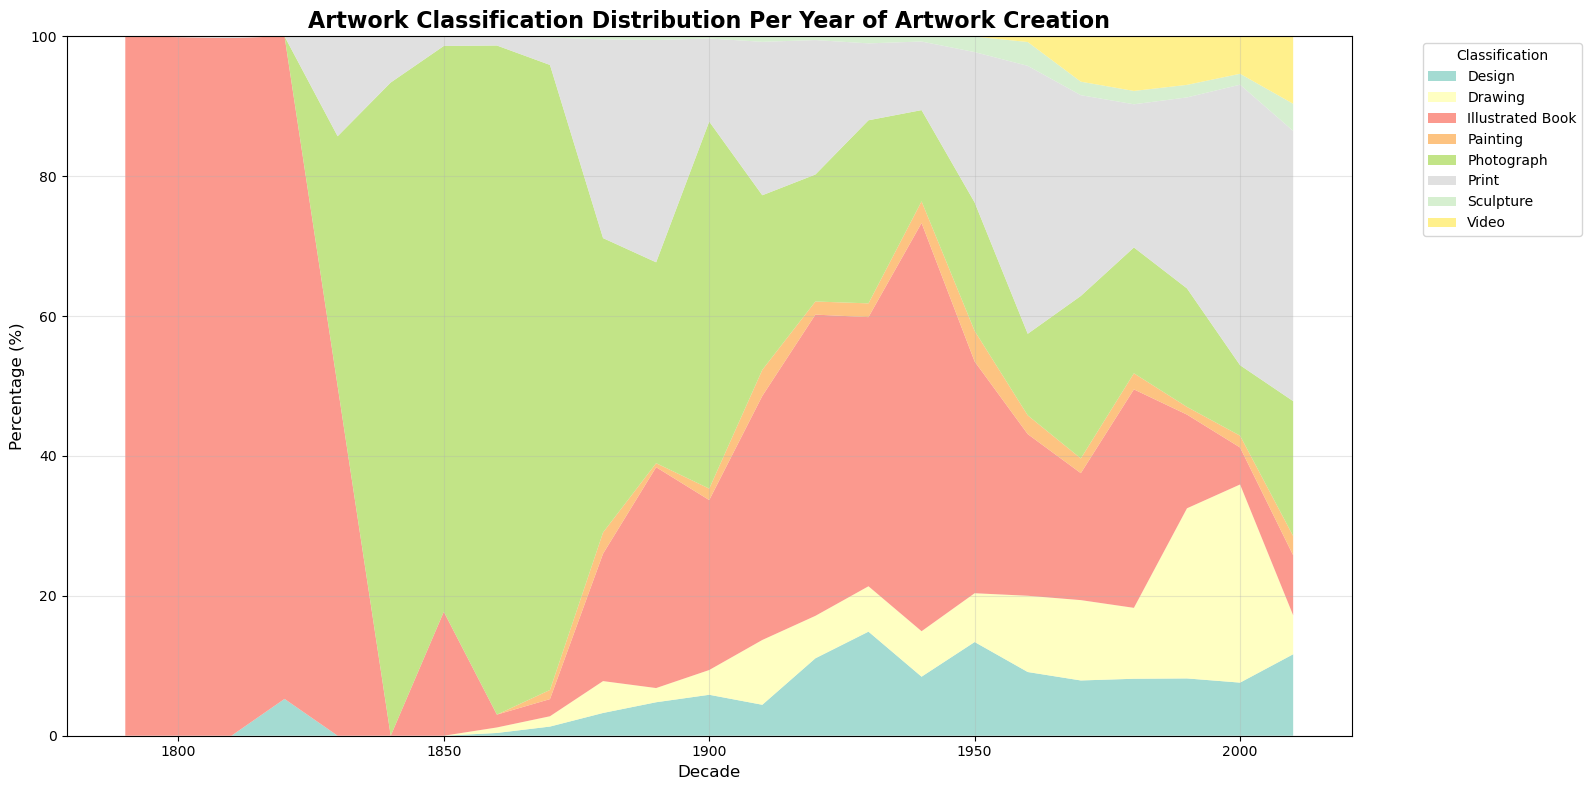


Artwork Classification Distribution by Decade (%):
Classification  Design  Drawing  Illustrated Book  Painting  Photograph  \
Decade                                                                    
1790              0.00     0.00            100.00      0.00        0.00   
1810              0.00     0.00             99.76      0.00        0.00   
1820              5.26     0.00             94.74      0.00        0.00   
1830              0.00     0.00             50.00      0.00       35.71   
1840              0.00     0.00              0.00      0.00       93.40   
1850              0.00     0.00             17.73      0.00       80.90   
1860              0.39     0.79              1.84      0.00       95.67   
1870              1.31     1.47              2.45      1.31       89.36   
1880              3.25     4.56             18.22      3.04       42.08   
1890              4.79     2.03             31.58      0.57       28.72   
1900              5.85     3.54             24.3

In [10]:
# Get all classifications
all_classes = unique_artworks['Classification'].value_counts().index.tolist()
print(f"Total unique classifications: {len(all_classes)}")
print("Top 10 classifications:")
print(unique_artworks['Classification'].value_counts().head(10))

# Use top 8 classifications for visualization
top_classes = unique_artworks['Classification'].value_counts().head(8).index.tolist()
df_class = unique_artworks[unique_artworks['Classification'].isin(top_classes)]

# Calculate percentage distribution by decade
class_by_decade = pd.crosstab(
    df_class['Decade'],
    df_class['Classification'],
    normalize='index'
) * 100

# Filter decades with sufficient data
decade_counts = unique_artworks.groupby('Decade').size()
valid_decades = decade_counts[decade_counts >= 5].index
class_by_decade = class_by_decade[class_by_decade.index.isin(valid_decades)]

print("\nDecades with data:")
print(class_by_decade.index.tolist())

# Plot stacked area chart
plt.figure(figsize=(16, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(class_by_decade.columns)))

plt.stackplot(
    class_by_decade.index,
    class_by_decade.values.T,
    labels=class_by_decade.columns.tolist(),
    colors=colors,
    alpha=0.8
)

plt.title('Artwork Classification Distribution Per Year of Artwork Creation', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Classification')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'data analysis image results/Artwork Classification Distribution Per Year of Artwork Creation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Display percentage distribution by decade
print("\nArtwork Classification Distribution by Decade (%):")
print(class_by_decade.round(2))

### Part 3.6: Analysis by Department (Collection Areas)


Total unique departments: 8
Department value counts:
Department
Drawings & Prints                        51040
Photography                              16170
Architecture & Design                     8939
Painting & Sculpture                      3000
Media and Performance                     2117
Film                                       971
Fluxus Collection                          449
Architecture & Design - Image Archive        8
Name: count, dtype: int64


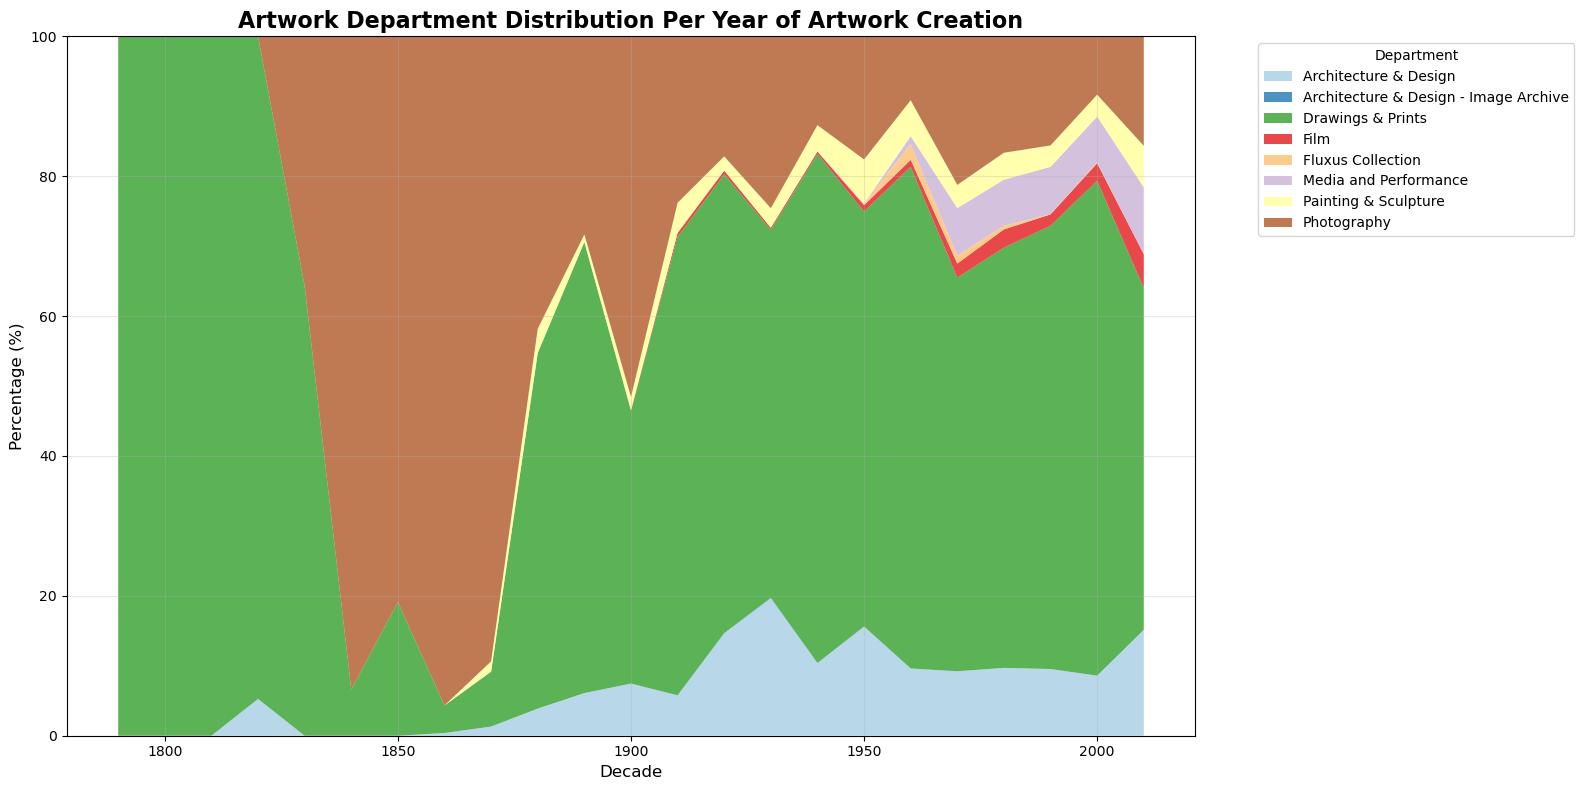


Artwork Department Distribution by Decade (%):
Department  Architecture & Design  Architecture & Design - Image Archive  \
Decade                                                                     
1790                         0.00                                   0.00   
1810                         0.00                                   0.00   
1820                         5.26                                   0.00   
1830                         0.00                                   0.00   
1840                         0.00                                   0.00   
1850                         0.00                                   0.00   
1860                         0.39                                   0.00   
1870                         1.31                                   0.00   
1880                         3.88                                   0.00   
1890                         6.10                                   0.00   
1900                         7.46       

In [11]:
# Use unique artworks to avoid counting the same artwork multiple times
df_dept = unique_artworks.copy()

# Get all departments
all_depts = df_dept['Department'].value_counts().index.tolist()
print(f"\nTotal unique departments: {len(all_depts)}")
print("Department value counts:")
print(df_dept['Department'].value_counts())

# Select top 8 most frequent departments
top_depts = df_dept['Department'].value_counts().head(8).index.tolist()
df_dept = df_dept[df_dept['Department'].isin(top_depts)]

# Calculate percentage distribution by decade
dept_by_decade = pd.crosstab(
    df_dept['Decade'],
    df_dept['Department'],
    normalize='index'
) * 100

# Filter decades with sufficient data
dept_by_decade = dept_by_decade[dept_by_decade.index.isin(valid_decades)]

# Create stacked area chart
plt.figure(figsize=(16, 8))
colors = plt.cm.Paired(np.linspace(0, 1, len(dept_by_decade.columns)))

plt.stackplot(
    dept_by_decade.index,
    dept_by_decade.values.T,
    labels=dept_by_decade.columns.tolist(),
    colors=colors,
    alpha=0.8
)

plt.title('Artwork Department Distribution Per Year of Artwork Creation', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Department')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    'data analysis image results/Artwork Department Distribution Per Year of Artwork Creation.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Display percentage distribution by decade
print("\nArtwork Department Distribution by Decade (%):")
print(dept_by_decade.round(2))